In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap joblib streamlit jupyterlab

  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
Using cached streamlit-1.55.0-py3-none-any.whl (9.1 MB)
Using cached altair-6.0.0-py3-none-any.whl (795 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached cachetools-7.0.5-py3-none-any.whl (13 kB)
Usi


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [4]:
customer_churn = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
customer_churn.head(70)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,5122-CYFXA,Female,0,No,No,3,Yes,No,DSL,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,75.30,244.1,No
66,8627-ZYGSZ,Male,0,Yes,No,47,Yes,Yes,Fiber optic,No,...,No,No,No,No,One year,Yes,Electronic check,78.90,3650.35,No
67,3410-YOQBQ,Female,0,No,No,31,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,79.20,2497.2,No
68,3170-NMYVV,Female,0,Yes,Yes,50,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.15,930.9,No


In [5]:
#checking for missing values
customer_churn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
print(customer_churn.shape)
customer_churn.info()
customer_churn.describe(include="all")
customer_churn.isnull().sum()


(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

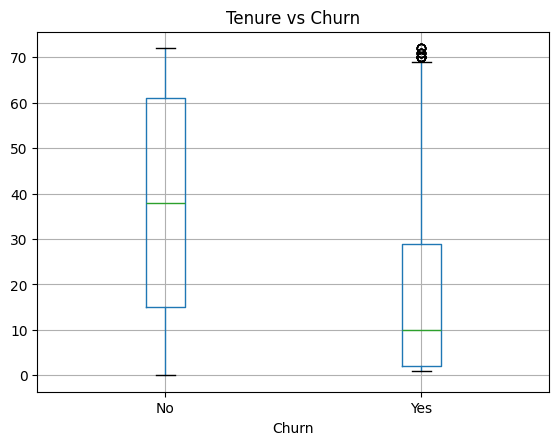

In [8]:
customer_churn.boxplot(column='tenure', by='Churn')
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()

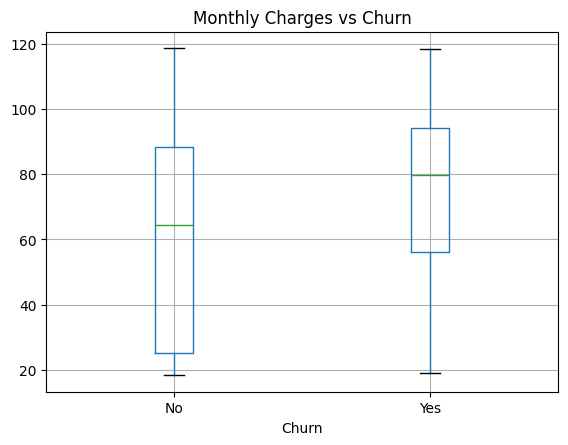

In [9]:
customer_churn.boxplot(column='MonthlyCharges', by='Churn')
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.show()

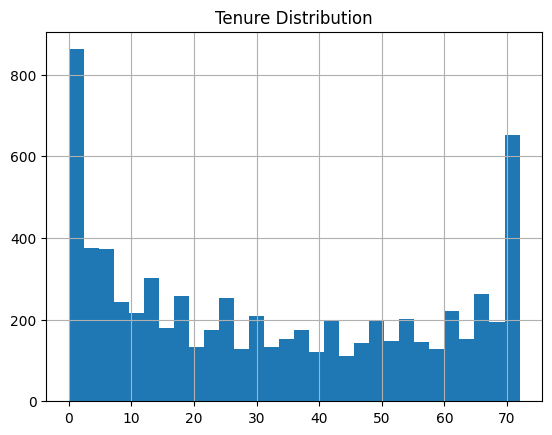

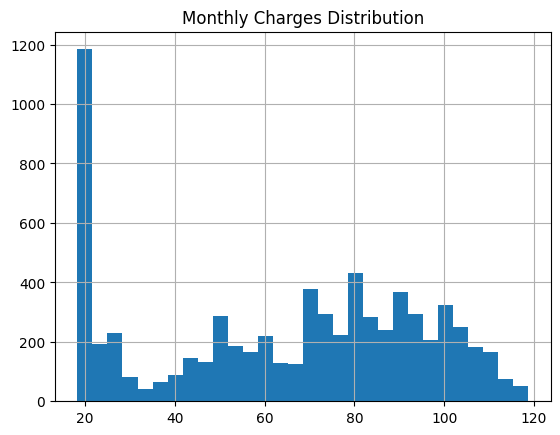

In [10]:
customer_churn['tenure'].hist(bins=30)
plt.title("Tenure Distribution")
plt.show()

customer_churn['MonthlyCharges'].hist(bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

Analyze Categorical Features

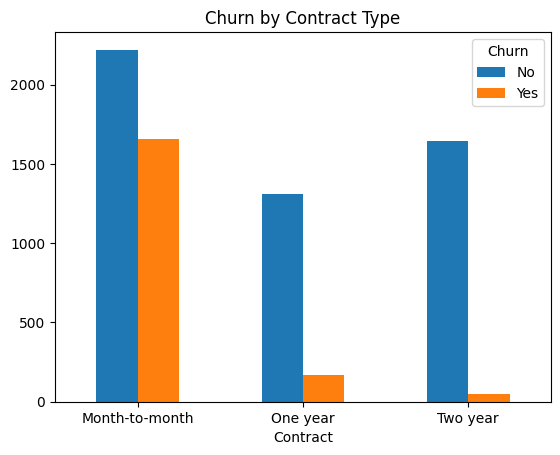

In [11]:
pd.crosstab(customer_churn['Contract'], customer_churn['Churn']).plot(kind='bar')
plt.title("Churn by Contract Type")
plt.xticks(rotation=0)
plt.show()

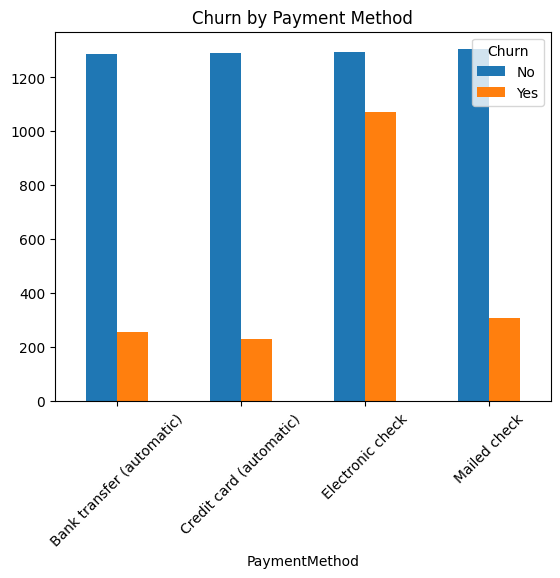

In [13]:
pd.crosstab(customer_churn['PaymentMethod'], customer_churn['Churn']).plot(kind='bar')
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

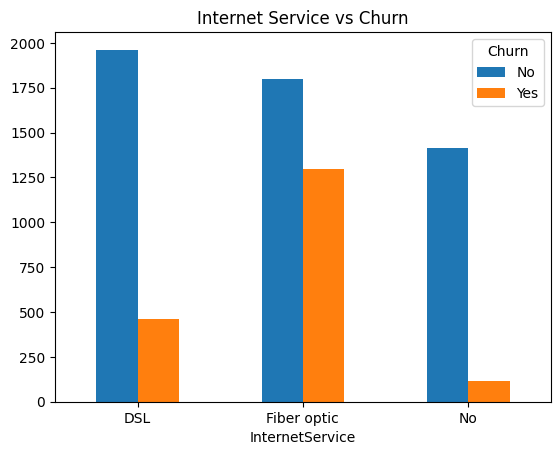

In [14]:
pd.crosstab(customer_churn['InternetService'], customer_churn['Churn']).plot(kind='bar')
plt.title("Internet Service vs Churn")
plt.xticks(rotation=0)
plt.show()

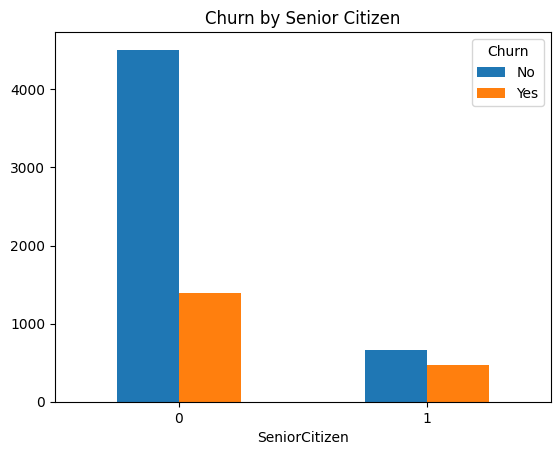

In [15]:
pd.crosstab(customer_churn['SeniorCitizen'], customer_churn['Churn']).plot(kind='bar')
plt.title("Churn by Senior Citizen")
plt.xticks(rotation=0)
plt.show()

In [16]:
#drop customerID column as it is not useful for prediction
customer_churn.drop("customerID", axis=1, inplace=True)


In [17]:
# Encode categorical variables
le = LabelEncoder()
for col in customer_churn.select_dtypes("object"):
    customer_churn[col] = le.fit_transform(customer_churn[col])


In [18]:
# Split the data into features and target variable
X = customer_churn.drop("Churn", axis=1)
y = customer_churn["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
# Build and train the Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Make predictions
y_pred = model.predict(X_test)


In [22]:
# Evaluate the model
accuracy_score(y_test, y_pred)


0.8069552874378992

In [23]:
# Confusion Matrix
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.68      0.51      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



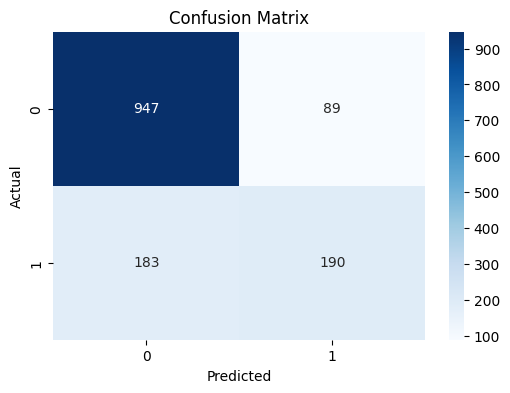

In [24]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


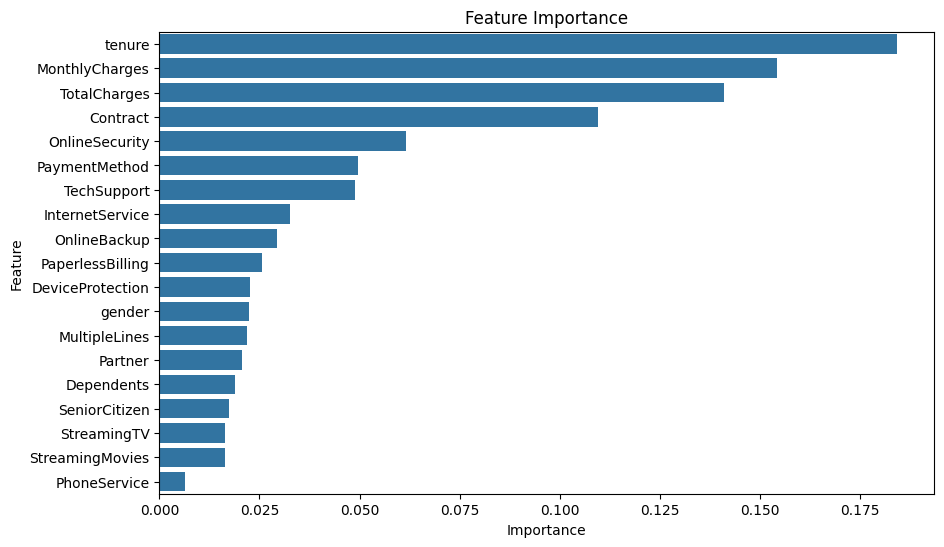

In [25]:
# Feature Importance
importances = model.feature_importances_
feat = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat = feat.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()


### Key Insights:
- Customers with month-to-month contracts churn the most
- High monthly charges increase churn
- New customers (low tenure) are more likely to leave
- Electronic check users have high churn

### Recommendations:
- Promote long-term contracts
- Improve onboarding experience
- Offer discounts for high-paying customers
- Encourage automatic payments

